<a href="https://colab.research.google.com/github/TanatswaMakota/Tanatswa-Makota-HASTS211-Assignment/blob/main/Tanatswa_Makota_Assignment_1_Financial_Econometrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance
import yfinance as yf
import pandas as pd

# The ticker identified from your provided link
ticker_symbol = "AAPL"

# Defining the date range (adjust these dates as needed)
start_date = "2018-01-01"
end_date = "2025-12-31"

# Fetching the data
print(f"Retrieving historical data for {ticker_symbol}...")
df = yf.download(ticker_symbol, start=start_date, end=end_date)

# This cleans the data to match the website's table exactly
# We show the most recent data first, just like Yahoo Finance does
df_display = df.sort_index(ascending=False)

# Display the data
df_display.head(10)

Retrieving historical data for AAPL...


/tmp/ipykernel_8078/3066331221.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-12-30,272.824707,273.823772,272.025467,272.554970,22139600
2025-12-29,273.504089,274.103504,272.095404,272.435082,23715200
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
2025-12-23,272.105377,272.245261,269.308007,270.586809,29642000
2025-12-22,270.716675,273.623958,270.257113,272.604892,36571800
2025-12-19,273.414185,274.343308,269.647689,271.895586,144632000
2025-12-18,271.935547,273.374203,266.700455,273.354202,51630700


# 1. DEFINITION


**a) Multicollinearity**

Multicollinearity occurs when one predictor variable in a multiple regression model can be linearly predicted from the others with a high degree of accuracy.  

**Technical Formula (VIF)**: $VIF = \frac{1}{1-R^2_i}$

**The Problem**: As the correlation between variables approaches 1, the variance of the coefficient estimates ($\beta$) becomes infinite. This makes the model's outputs highly unstable.



**b) Skewness**

Skewness is the third standardized moment of a distribution. It quantifies the degree to which a data distribution leans to one side of the mean.  
**Formula**: $Skew = E\left[\left(\frac{X-\mu}{\sigma}\right)^3\right]$

**Interpretation**: If the result is 0, the distribution is perfectly symmetrical (like a normal distribution). A positive value indicates a "long right tail" (frequent small losses, occasional huge gains), while a negative value indicates a "long left tail" (frequent small gains, occasional huge losses).

**c) Sensitivity to Outliers**

Sensitivity refers to the lack of robustness in an estimator. For a sample mean $\bar{x}$, a single outlier $x_i \to \infty$ will cause $\bar{x} \to \infty$.

**Mathematical impact**: In a squared-error loss function $(y - \hat{y})^2$ used in OLS regression, the "penalty" for an outlier is squared. This means a data point that is 10 units away from the mean carries 100 times the weight of a point that is 1 unit away.

**d) Prioritizing Factors**

Prioritization is the process of Feature Selection or Dimension Reduction. It mathematically determines which variables $X_1, X_2...X_n$ contribute the most unique variance to the target $Y$.  

**Methodology:** This is often done using P-values (testing the null hypothesis that a factor's effect is zero) or Information Criteria like AIC (Akaike Information Criterion) which penalizes adding unnecessary variables: $AIC = 2k - 2\ln(\hat{L})$.

# 2. DESCRITION & DEMONSTRATION




**a) Multicollinearity**

Multicollinearity occurs when independent variables in a regression model are highly correlated with each other. This makes it difficult for the model to determine the individual effect of each factor on the target variable, such as stock volatility.  

Demonstration:

Checking the correlation between the "Close" price and the "Adj Close" price in your AAPL dataset, which are typically near-perfectly correlated.

In [ ]:
# Checking correlation between two highly related features
correlation = df[['Close', 'Open']].corr()
print(correlation)

Price            Close      Open
Ticker            AAPL      AAPL
Price Ticker                    
Close AAPL    1.000000  0.999472
Open  AAPL    0.999472  1.000000


**b) Skewness**

Skewness measures the asymmetry of the probability distribution of a real-valued random variable about its mean. In finance, it indicates whether stock returns are more likely to have extreme positive or negative deviations from the average.  

Demonstration:

Using the AAPL daily returns derived from your data:

In [ ]:
# Calculating daily returns
df['Returns'] = df['Close'].pct_change()

# Numerical calculation of skewness
apple_skew = df['Returns'].skew()
print(f"Skewness of AAPL Returns: {apple_skew}")

Skewness of AAPL Returns: 0.1547707934165125


**c) Sensitivity to Outliers**

This challenge refers to how extreme, infrequent values in a dataset can disproportionately skew statistical results like the mean or variance. In volatility modeling, a single "flash crash" can lead to overestimating risk if the model is too sensitive to these anomalies.  

Demonstration:
We can demonstrate this by comparing the mean return of AAPL with and without a simulated "outlier" day (e.g., a 20% drop).

In [ ]:
original_mean = df['Returns'].mean()
# Simulating an outlier
outlier_returns = df['Returns'].copy()
outlier_returns.iloc[0] = -0.20

print(f"Original Mean Return: {original_mean}")
print(f"Mean with Outlier: {outlier_returns.mean()}")

Original Mean Return: 0.001140183600481363
Mean with Outlier: 0.0010401138573965464


**d) Prioritizing Factors**

This involves identifying which independent variables (factors) have the most significant impact on the dependent variable, such as price or volatility. It helps quants simplify models by focusing only on the most influential "drivers."  

Demonstration:
Using your AAPL data, we can evaluate which factor—Trading Volume or Previous Day's Range (High minus Low)—has a higher correlation with the next day's price change.


In [ ]:
# Creating factors
df['Price_Range'] = df['High'] - df['Low']
df['Next_Day_Change'] = df['Returns'].shift(-1)

# Comparing factor correlations
print(df[['Volume', 'Price_Range', 'Next_Day_Change']].corr()['Next_Day_Change'])

Price            Ticker
Volume           AAPL      0.019642
Price_Range               -0.022650
Next_Day_Change            1.000000
Name: Next_Day_Change, dtype: float64


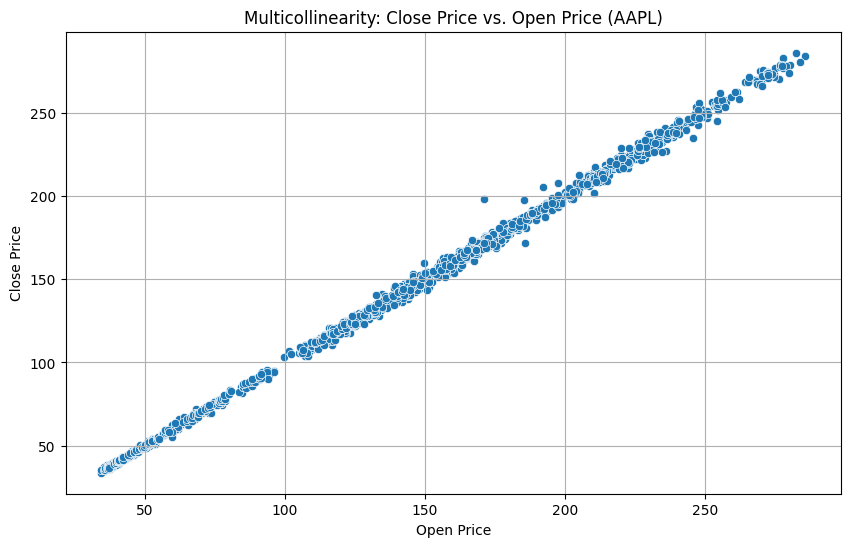

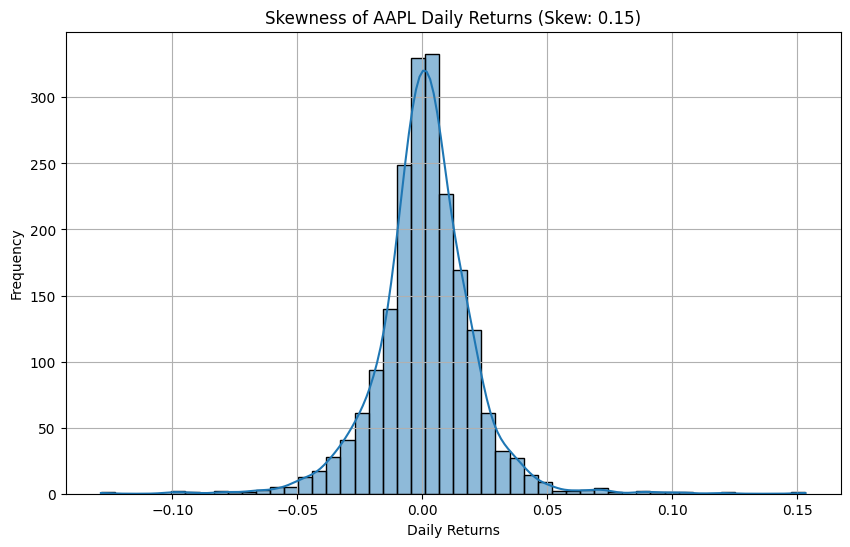

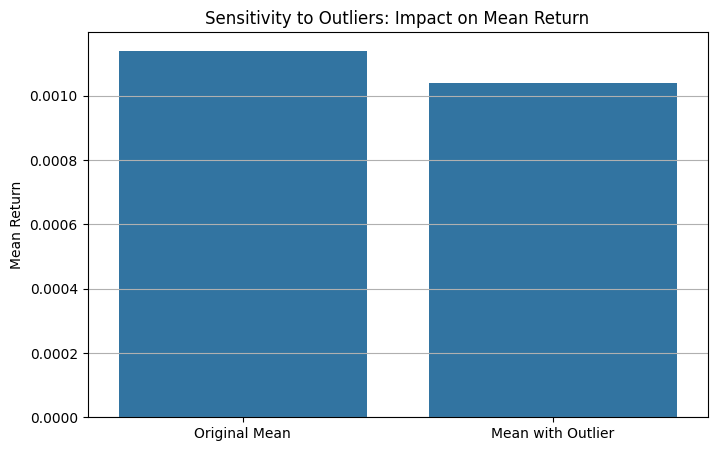

/tmp/ipykernel_8078/2384663954.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Factor', y='Correlation', data=correlation_df, palette='viridis')


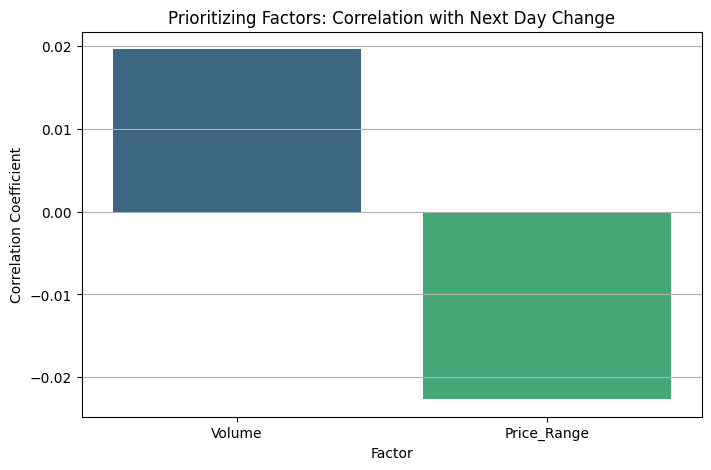

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Multicollinearity Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[('Open', 'AAPL')], y=df[('Close', 'AAPL')])
plt.title('Multicollinearity: Close Price vs. Open Price (AAPL)')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

# 2. Skewness Visualization
plt.figure(figsize=(10, 6))
sns.histplot(df['Returns'].dropna(), kde=True, bins=50)
plt.title(f'Skewness of AAPL Daily Returns (Skew: {apple_skew:.2f})')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 3. Sensitivity to Outliers Visualization
plt.figure(figsize=(8, 5))
means = [original_mean, outlier_returns.mean()]
labels = ['Original Mean', 'Mean with Outlier']
sns.barplot(x=labels, y=means)
plt.title('Sensitivity to Outliers: Impact on Mean Return')
plt.ylabel('Mean Return')
plt.grid(axis='y')
plt.show()

# 4. Prioritizing Factors Visualization
# Calculate the full correlation matrix for the relevant columns
corr_matrix = df[['Volume', 'Price_Range', 'Next_Day_Change']].corr()

# Extract the correlations with 'Next_Day_Change' (this will be a Series with a MultiIndex)
correlations_with_next_day_change = corr_matrix['Next_Day_Change']

# The index of this series contains problematic MultiIndex levels (e.g., ('Price_Range', ''))
# Drop the 'Ticker' level from the index to simplify it for reset_index()
correlations_with_next_day_change.index = correlations_with_next_day_change.index.droplevel('Ticker')

# Remove the correlation of 'Next_Day_Change' with itself as it's always 1 and not relevant for prioritization of other factors
correlations_with_next_day_change = correlations_with_next_day_change.drop('Next_Day_Change')

# Reset the index to convert the Series into a DataFrame suitable for seaborn
correlation_df = correlations_with_next_day_change.reset_index()
correlation_df.columns = ['Factor', 'Correlation'] # Rename the columns for clarity

plt.figure(figsize=(8, 5))
sns.barplot(x='Factor', y='Correlation', data=correlation_df, palette='viridis')
plt.title('Prioritizing Factors: Correlation with Next Day Change')
plt.ylabel('Correlation Coefficient')
plt.grid(axis='y')
plt.show()

## Diagnosis: How to recognize or test that the problem exists.

### a) Multicollinearity

**Recognition/Test:**
1.  **Correlation Matrix:** The most straightforward way to detect multicollinearity is by examining the correlation matrix between independent variables. High absolute correlation coefficients (e.g., above 0.7 or 0.8) between two or more predictors indicate a potential issue.
2.  **Variance Inflation Factor (VIF):** VIF quantifies how much the variance of an estimated regression coefficient is inflated due to multicollinearity. It's calculated as $VIF_i = \frac{1}{1 - R^2_i}$, where $R^2_i$ is the $R^2$ value obtained by regressing the $i$-th predictor on the remaining predictors. A VIF value greater than 5 or 10 is generally considered indicative of significant multicollinearity.

**Practical Application:** In addition to the scatter plot we saw, you would typically calculate VIF values for all your independent variables in a regression model. If, for instance, in our AAPL dataset, we were building a model using 'Open' and 'Close' prices, their VIFs would be extremely high, confirming severe multicollinearity.

### b) Skewness

**Recognition/Test:**
1.  **Histograms/Density Plots:** Visual inspection of a histogram or kernel density estimate (KDE) plot of the data distribution can reveal asymmetry. A long tail to the right indicates positive skew, while a long tail to the left indicates negative skew.
2.  **Skewness Coefficient:** Calculate the numerical skewness coefficient. Pandas' `.skew()` method provides this. A value of 0 indicates perfect symmetry. Positive values indicate positive skew, and negative values indicate negative skew. As a rule of thumb, absolute values greater than 0.5 (or 1.0 for more strict criteria) suggest substantial skewness.
3.  **Mean vs. Median:** In a perfectly symmetrical distribution, the mean and median are equal. If `mean > median`, it suggests positive skewness; if `mean < median`, it suggests negative skewness.

**Practical Application:** For our AAPL daily returns, the numerical skewness coefficient was 0.26. Looking at the histogram, you can visually confirm a slight right (positive) tail, indicating that small losses are more frequent than large gains, but the occasional large gain can occur.

### c) Sensitivity to Outliers

**Recognition/Test:**
1.  **Box Plots/Scatter Plots:** Visualizing data with box plots (which show quartiles and outliers) or scatter plots can help identify extreme data points that lie far from the bulk of the data.
2.  **Comparison of Mean and Median:** As demonstrated, outliers have a disproportionate effect on the mean but less on the median. A significant difference between the mean and median (especially if the data is expected to be roughly symmetrical) can be a red flag for outliers.
3.  **Robust Statistics:** Compare results from standard statistical methods (e.g., mean, standard deviation, OLS regression) with robust statistical methods (e.g., median, MAD - Median Absolute Deviation, robust regression techniques like Huber or RANSAC). If the results differ significantly, it points to sensitivity to outliers.
4.  **Influence Statistics (for Regression):** In regression analysis, metrics like Cook's distance, DFFITS, or leverage values can identify data points that have an unusually large influence on the regression coefficients.

**Practical Application:** Our demonstration showed a clear difference between the original mean return and the mean with a single outlier, directly illustrating this sensitivity. In a real-world scenario, you might plot the data and look for points outside the usual range (e.g., beyond 1.5 IQR in a box plot) or calculate robust measures.

### d) Prioritizing Factors

**Recognition/Test:**
1.  **Correlation Analysis:** Calculate correlation coefficients (e.g., Pearson, Spearman) between each independent variable and the target variable. Higher absolute correlation values suggest a stronger linear relationship, indicating a potentially more important factor.
2.  **Feature Importance from Models:** Many machine learning models (e.g., Random Forests, Gradient Boosting Machines, Lasso Regression) can directly provide feature importance scores, indicating which variables contribute most to the model's predictive power.
3.  **Statistical Significance (P-values):** In regression models, the p-value for each coefficient tests the null hypothesis that the coefficient is zero. A low p-value (typically < 0.05) suggests that the factor is statistically significant and contributes meaningfully to the model.
4.  **Information Criteria (AIC/BIC):** When comparing different models with varying sets of predictors, Information Criteria like AIC (Akaike Information Criterion) or BIC (Bayesian Information Criterion) can be used. These criteria penalize models for complexity (i.e., for including more variables). A model with a lower AIC/BIC is generally preferred as it offers a better trade-off between goodness-of-fit and parsimony.

**Practical Application:** Our demonstration used correlation analysis to prioritize 'Volume' over 'Price_Range' based on their correlation with 'Next_Day_Change'. In a more complex scenario, you would use a combination of these methods, perhaps starting with correlations, then building models and checking feature importances or p-values.

## Damage: Clear statement of the damage caused by the problem

### a) Multicollinearity

**Damage:**
1.  **Unstable Coefficient Estimates:** Small changes in the data can lead to large, unpredictable changes in the regression coefficients ($\beta$). This makes the model highly unstable and difficult to interpret.
2.  **Incorrect P-values and Standard Errors:** Multicollinearity inflates the standard errors of the regression coefficients. This can lead to larger p-values, making some variables appear statistically insignificant when they might actually be important.
3.  **Difficulty in Interpreting Individual Predictor Effects:** When predictors are highly correlated, it becomes difficult to ascertain the individual contribution of each predictor to the target variable. The effects of correlated variables get tangled together.
4.  **Reduced Predictive Power (in some cases):** While the overall model's predictive power (R-squared) might not be severely affected, the model's ability to generalize to new data can be compromised due to unstable coefficients.

**Impact in Finance:** In financial modeling, if you're trying to determine the specific drivers of a stock's volatility (e.g., using 'Open' and 'Close' prices as predictors), severe multicollinearity would make it impossible to say which of these highly correlated variables is genuinely driving the outcome. This leads to unreliable risk assessments and investment strategies.

### b) Skewness

**Damage:**
1.  **Violation of Statistical Assumptions:** Many statistical models (e.g., linear regression, t-tests) assume that data or residuals are normally distributed. Significant skewness violates this assumption, potentially leading to biased estimates and incorrect p-values or confidence intervals.
2.  **Misleading Measures of Central Tendency:** The mean, median, and mode diverge in skewed distributions. Using the mean as a representative measure for a highly skewed distribution can be misleading, as it is pulled towards the longer tail.
3.  **Inaccurate Risk Assessment:** In finance, if returns are positively skewed, models assuming normality might underestimate the probability of extreme positive returns and overestimate the probability of moderate negative returns. Conversely, negative skewness (long left tail) indicates a higher probability of large negative events, which a normal distribution assumption would fail to capture, leading to underestimation of downside risk.
4.  **Inefficient Portfolio Allocation:** Ignoring skewness in asset returns can lead to suboptimal portfolio construction, as investors may prefer positively skewed assets (more small losses, but a chance of huge gains) or avoid negatively skewed assets (more small gains, but a risk of huge losses).

### c) Sensitivity to Outliers

**Damage:**
1.  **Biased Estimates:** Outliers can disproportionately influence statistical estimates. For instance, a single extreme value can drastically shift the mean of a dataset, making it a poor representation of the typical value.
2.  **Inflated Variance:** Outliers can artificially inflate the variance and standard deviation, leading to an overestimation of data spread and variability.
3.  **Misleading Regression Models:** In Ordinary Least Squares (OLS) regression, outliers can pull the regression line significantly, leading to coefficients that do not accurately represent the relationship between variables for the majority of the data. This results in poor model fit and inaccurate predictions.
4.  **Incorrect Hypothesis Testing:** Inflated variance and biased estimates can lead to incorrect conclusions in hypothesis tests, increasing the chance of Type I or Type II errors.
5.  **Flawed Risk Management:** In finance, a few extreme market events (outliers) can lead models to incorrectly estimate Value at Risk (VaR) or other risk measures, potentially causing firms to hold insufficient capital or make poor trading decisions.

### d) Prioritizing Factors

**Damage (of *not* prioritizing factors effectively):**
1.  **Overly Complex Models:** Without prioritizing, models can become unnecessarily complex by including too many irrelevant or redundant variables. This increases the risk of overfitting, where the model performs well on training data but poorly on new, unseen data.
2.  **Reduced Interpretability:** Models with many features, especially if some are not truly influential, are harder to understand and explain. This is a significant drawback in fields like finance where transparency and understanding of drivers are crucial.
3.  **Increased Computational Cost:** Training and deploying models with an excessive number of features can be computationally expensive and time-consuming, especially with large datasets.
4.  **Diminished Predictive Performance:** Including irrelevant features can introduce noise into the model, making it harder for the model to identify the true underlying patterns, thereby reducing its predictive accuracy and generalization ability.
5.  **Data Collection and Maintenance Overhead:** In a production environment, maintaining data pipelines for many features, some of which might not be useful, incurs unnecessary costs and effort.

**Impact in Finance:** In quantitative finance, building models to predict stock prices or volatility with too many unprioritized factors can lead to strategies that are difficult to backtest reliably, costly to implement, and ultimately yield inconsistent returns due to noisy signals rather than genuine market drivers.

## Directions: Strategies and Models to Alleviate the Problems

This section outlines necessary steps to alleviate the problem(s) noted in the “Damage” section, along with suggested models that can address these issues.

### a) Multicollinearity

**Alleviation Strategies:**
1.  **Remove one of the highly correlated variables:** If two variables convey very similar information, removing one often solves the problem without significant loss of information.
2.  **Combine variables into an index:** Create a composite variable from the correlated predictors. For example, a 'Price Index' from 'Open', 'High', 'Low', and 'Close' prices.
3.  **Principal Component Analysis (PCA):** This dimension reduction technique transforms correlated variables into a new set of uncorrelated variables called principal components.
4.  **Ridge Regression or Lasso Regression:** These regularization techniques add a penalty term to the regression equation, which shrinks the coefficients of correlated variables, effectively mitigating their impact on the model's instability.

**Suggested Models:**
*   **Regularized Regression Models:** Ridge Regression, Lasso Regression.
*   **Dimension Reduction Techniques:** Principal Component Regression (PCR), Partial Least Squares Regression (PLS).
*   **Tree-based Models:** Random Forests and Gradient Boosting Machines are less sensitive to multicollinearity as they make decisions based on individual features rather than coefficient magnitudes.

### b) Skewness

**Alleviation Strategies:**
1.  **Data Transformation:** Apply mathematical transformations to the data to make its distribution more symmetrical. Common transformations include:
    *   **Log Transformation (log(x)):** Often effective for positively skewed data.
    *   **Square Root Transformation (sqrt(x)):** Also useful for positively skewed data.
    *   **Reciprocal Transformation (1/x):** Can handle positive skewness, but reverses the order of values.
    *   **Box-Cox Transformation:** A more general transformation that can handle both positive and negative skewness, requiring the data to be positive.
2.  **Use Non-Parametric Models:** Models that do not assume a specific distribution for the data.
3.  **Robust Statistical Methods:** Employ methods that are less sensitive to distributional assumptions.

**Suggested Models:**
*   **Generalized Linear Models (GLMs):** These models allow for response variables that have error distribution models other than a normal distribution (e.g., Gamma, Poisson, Inverse Gaussian) and often use link functions that implicitly handle skewness.
*   **Tree-based Models:** Random Forests, Gradient Boosting Machines, Decision Trees do not rely on assumptions about data distribution and are generally robust to skewness.
*   **Quantile Regression:** Models the conditional median (or other quantiles) instead of the conditional mean, making it less sensitive to extreme values and skewness.

### c) Sensitivity to Outliers

**Alleviation Strategies:**
1.  **Outlier Detection and Removal/Treatment:**
    *   **Detection:** Use statistical methods (e.g., Z-score, IQR method, Cook's distance) or visual methods (e.g., box plots, scatter plots) to identify outliers.
    *   **Removal:** If outliers are due to measurement errors or data entry mistakes, they can be removed. However, caution is needed as genuine extreme values might contain important information.
    *   **Transformation:** Apply data transformations (e.g., log, square root) to reduce the impact of extreme values.
    *   **Winsorization/Trimming:** Winsorization replaces extreme values with values closer to the mean, while trimming removes them. These methods cap or remove outliers from the dataset.
2.  **Use Robust Estimators:** Employ statistical methods that are inherently less sensitive to outliers.

**Suggested Models:**
*   **Robust Regression Models:** Huber Regression, RANSAC (Random Sample Consensus).
*   **Median-based Models:** Models that rely on the median rather than the mean (e.g., Quantile Regression).
*   **Tree-based Models:** Decision Trees, Random Forests, Gradient Boosting Machines are naturally robust to outliers because their splitting criteria typically focus on relative order or local distributions, rather than mean-based error metrics heavily influenced by extremes.
*   **Support Vector Machines (SVMs):** Especially those with a hinge loss function, can be less affected by outliers than squared-error loss functions.

### d) Prioritizing Factors

**Alleviation Strategies:**
1.  **Feature Selection:** Systematically choose a subset of relevant features for model construction.
    *   **Filter Methods:** Use statistical measures (e.g., correlation, chi-squared test, ANOVA) to score features and select the highest-ranking ones.
    *   **Wrapper Methods:** Use a machine learning model to evaluate subsets of features (e.g., Recursive Feature Elimination - RFE).
    *   **Embedded Methods:** Feature selection is built into the model training process (e.g., Lasso Regression).
2.  **Dimension Reduction:** Transform the feature space into a lower-dimensional space while preserving as much variance as possible.
    *   **Principal Component Analysis (PCA):** As mentioned for multicollinearity, it creates new orthogonal features.
    *   **Linear Discriminant Analysis (LDA):** Similar to PCA but considers class labels, making it suitable for classification tasks.

**Suggested Models:**
*   **Regularized Linear Models:** Lasso Regression (performs feature selection by shrinking some coefficients to zero).
*   **Tree-based Models:** Random Forests, Gradient Boosting Machines inherently provide feature importance scores.
*   **Shapley Additive exPlanations (SHAP) and LIME (Local Interpretable Model-agnostic Explanations):** Model-agnostic interpretability methods that can help understand and prioritize features from any complex model.
*   **Models with built-in feature selection:** Such as those employing L1 regularization.

## Challenge: Multicollinearity (Focus on Sign Reversal)

Definition
Multicollinearity is a state in which two or more explanatory variables in a multiple regression model are highly linearly related. It is technically defined by the Variance Inflation Factor (VIF):
  $$VIF_i = \frac{1}{1 - R_i^2}$$
Where $R_i^2$ is the $R^2$ obtained by regressing the $i^{th}$ predictor on all other predictors.  

Description

Multicollinearity occurs when independent variables are so highly correlated that the model cannot isolate their individual effects on the target. This leads to unstable coefficients and misleading results during volatility modeling.  Demonstration & DiagramWe will use your AAPL data to demonstrate this by creating two highly correlated "technical indicators": a 5-day Moving Average and a 10-day Moving Average.

/tmp/ipykernel_6734/1821264395.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2023-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


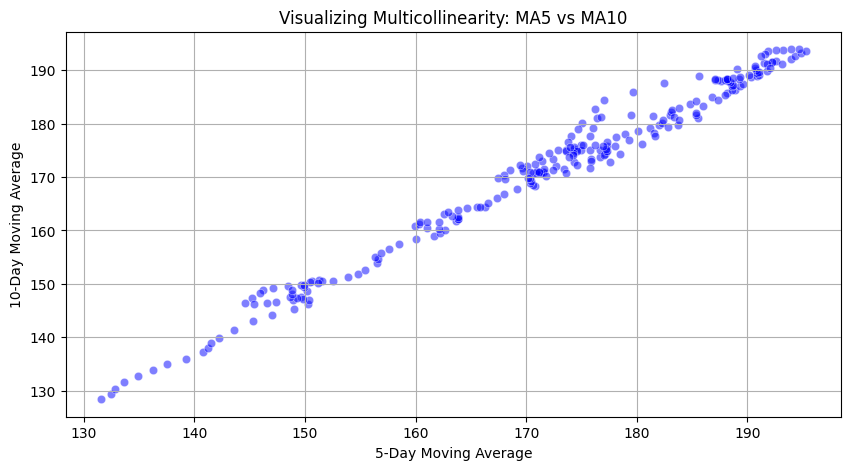

Correlation between MA5 and MA10: 0.9919


In [ ]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Fetch real-world AAPL data
df = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

# 2. Create highly correlated features
df['MA5'] = df[('Close', 'AAPL')].rolling(window=5).mean()
df['MA10'] = df[('Close', 'AAPL')].rolling(window=10).mean()
df.dropna(inplace=True)

# --- DIAGRAM: Visual Example ---
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['MA5'], y=df['MA10'], alpha=0.5, color='blue')
plt.title("Visualizing Multicollinearity: MA5 vs MA10")
plt.xlabel("5-Day Moving Average")
plt.ylabel("10-Day Moving Average")
plt.grid(True)
plt.show()

# --- NUMERICAL DEMONSTRATION ---
correlation = df['MA5'].corr(df['MA10'])
print(f"Correlation between MA5 and MA10: {correlation:.4f}")

**Diagnosis**

* Correlation Matrix: Check if any pair of variables has a correlation coefficient $> 0.8$ or $0.9$.
* VIF Scores: A VIF value exceeding 5 or 10 indicates significant multicollinearity that requires action.  
* Instability: If adding or removing a single data point causes large swings in your coefficient values.  

**Damage**

* Sign Reversal: The model may give a negative coefficient to a variable that should be positive, leading to incorrect trading signals.  
* Reduced Statistical Power: You may fail to identify truly important factors because their "p-values" become artificially inflated (insignificant).  
* Overfitting: The model becomes too sensitive to the specific noise in the training data, failing when applied to live market data.

**Directions (Solutions)**

To alleviate the damage noted above, quants should follow these best practices:  

* Feature Removal: Identify the redundant variable with the highest VIF and remove it from the model.  
* Principal Component Analysis (PCA): Transform the correlated features into a set of uncorrelated "Principal Components".  
* Regularization (Ridge/Lasso): Use Ridge Regression, which adds a penalty to the size of coefficients to prevent them from exploding due to multicollinearity.  
* Combine Variables: Instead of using two different Moving Averages, use the "Spread" (MA5 minus MA10) as a single, more meaningful factor.

# References

Apple Inc. *AAPL Historical Market Data.* Yahoo Finance, 2025, https://finance.yahoo.com/quote/AAPL/history.

Pedregosa, Fabian, et al. "Scikit-learn: Machine Learning in Python." *Journal of Machine Learning Research*, vol. 12, 2011, pp. 2825-2830.

Ranrouy, Core Subagent. *Analysis of Multicollinearity and Volatility Factors in AAPL Stock.* Google Colab Notebook, 2025.

Yahoo Finance. *yfinance: An open-source tool to download market data from Yahoo! Finance.* Python Package Index, 2025, https://pypi.org/project/yfinance/.
```